# RL Project — Highway-v0

**CentraleSupélec — Mention IA**

This notebook covers the **extension task**:
1. A hand-implemented DQN agent trained on `highway-v0`
2. A Stable-Baselines3 baseline on the same environment
3. Comparative evaluation (mean reward ± std over 50 runs)
4. Training curves, behaviour analysis, and a failure-mode discussion

## 0 — Setup

In [19]:
import sys, os, random, time
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
import highway_env

from tqdm.notebook import tqdm

from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

os.environ["SDL_VIDEODRIVER"] = "dummy"

print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Gym     : {gym.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Python  : 3.12.5
PyTorch : 2.10.0+cu126
Gym     : 1.2.3
Using device: cuda


## 1 — Different Environment Configurations

In [20]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 30,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
}

# --- Dense traffic baseline ---
DENSE_BASELINE_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
}

# --- Dense traffic, balanced safety ---
DENSE_BALANCED_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -3.0,
    "high_speed_reward": 0.45,
    "lane_change_reward": -0.05,
}

# --- Dense traffic, safety-first ---
DENSE_SAFETY_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -5.0,
    "high_speed_reward": 0.25,
    "lane_change_reward": -0.08,
}

EXPERIMENT_CONFIGS = {
    "dense_baseline": DENSE_BASELINE_CONFIG,
    "dense_balanced": DENSE_BALANCED_CONFIG,
    "dense_safety": DENSE_SAFETY_CONFIG,
}

EVAL_SEEDS = list(range(50))

def make_env(config=None, render_mode=None):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

env = make_env(SHARED_CORE_CONFIG)
obs, _ = env.reset()
print("Observation shape :", obs.shape)
print("Action space      :", env.action_space)
print("Flattened obs size:", obs.flatten().shape[0])

Observation shape : (10, 5)
Action space      : Discrete(5)
Flattened obs size: 50


### Observation space

Each observation is a **10 × 5 matrix** — one row per vehicle (including ego), five features each: `[presence, x, y, vx, vy]`, normalized and relative to the ego vehicle. We flatten it to a 50-dimensional vector before feeding it to the network.

## 2 — DQN Implementation

We implement the full DQN algorithm from scratch following the original Mnih et al. (2015) design:
- **Replay buffer** to break temporal correlations
- **Target network** updated periodically to stabilise training
- **ε-greedy exploration** with exponential decay

### 2.1 Replay Buffer

In [21]:
class ReplayBuffer:
    def __init__(self, capacity, obs_size):
        self.capacity = capacity
        self.pos = 0
        self.size = 0
        self.states      = np.zeros((capacity, obs_size), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_size), dtype=np.float32)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action, reward, terminated, next_state):
        self.states[self.pos]      = state.flatten()
        self.next_states[self.pos] = next_state.flatten()
        self.actions[self.pos]     = action
        self.rewards[self.pos]     = reward
        self.dones[self.pos]       = float(terminated)
        self.pos = (self.pos + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (self.states[idx], self.actions[idx], self.rewards[idx],
                self.dones[idx], self.next_states[idx])

    def __len__(self):
        return self.size

### 2.2 Neural Network

A small MLP with two hidden layers. The input is the flattened kinematic observation (50 features), and the output has one Q-value per discrete action.

In [22]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

### 2.3 DQN Agent

Key design choices:
- **Batch size**: 64 (larger than CartPole baseline because the highway state space is richer)
- **Buffer capacity**: 20 000 transitions
- **Target network sync**: every 200 steps
- **ε decay**: exponential from 0.9 → 0.05 over ~2 000 steps

In [23]:
class DQN:
    def __init__(
        self,
        obs_size,
        n_actions,
        gamma=0.99,
        batch_size=64,
        buffer_capacity=20_000,
        update_target_every=200,
        epsilon_start=0.9,
        epsilon_min=0.05,
        epsilon_decay=2000,
        learning_rate=1e-3,
        hidden_size=128,
        device=None
    ):
        self.device = device or torch.device("cpu")  # <-- must come first
        
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.update_target_every = update_target_every
        self.epsilon = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.n_steps = 0

        self.buffer = ReplayBuffer(buffer_capacity, obs_size)
        self.q_net = QNet(obs_size, n_actions, hidden_size).to(self.device)   # <-- now works
        self.target_net = deepcopy(self.q_net)  # already on device since copied from q_net
        self.target_net.eval()

        self.optimizer = optim.Adam(self.q_net.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()


    def get_action(self, state, epsilon=None):
        """Epsilon-greedy action selection."""
        if epsilon is None:
            epsilon = self.epsilon
        if random.random() < epsilon:
            return random.randrange(self.n_actions)
        state_t = torch.FloatTensor(state.flatten()).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.q_net(state_t)
        return q_values.argmax(dim=1).item()

    def update(self, state, action, reward, terminated, next_state):
        self.buffer.push(
            torch.FloatTensor(state.flatten()),
            action, reward, terminated,
            torch.FloatTensor(next_state.flatten()),
        )

        if len(self.buffer) < self.batch_size:
            return None
        
        states, actions, rewards, dones, next_states = self.buffer.sample(self.batch_size)
        states_t      = torch.from_numpy(states).to(self.device)
        next_states_t = torch.from_numpy(next_states).to(self.device)
        actions_t     = torch.from_numpy(actions).unsqueeze(1).to(self.device)
        rewards_t     = torch.from_numpy(rewards).to(self.device)
        dones_t       = torch.from_numpy(dones).to(self.device)

        q_current = self.q_net(states_t).gather(1, actions_t).squeeze(1)

        with torch.no_grad():
            q_next   = self.target_net(next_states_t).max(dim=1).values
            q_target = rewards_t + self.gamma * q_next * (1 - dones_t)

        loss = self.loss_fn(q_current, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.n_steps += 1

        if self.n_steps % self.update_target_every == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        self.epsilon = self.epsilon_min + (
            (self.epsilon_start - self.epsilon_min)
            * np.exp(-self.n_steps / self.epsilon_decay)
        )

        return loss.item()

## 3 — Training the DQN

We train for a fixed budget of episodes and log the episode reward plus the TD loss. Intermediate evaluations are run every `eval_every` episodes to track progress without waiting until the end.

In [24]:
def evaluate_agent(agent, config, eval_seeds=None, epsilon=0.0):
    if eval_seeds is None:
        eval_seeds = list(range(10))

    rewards = []
    for seed in eval_seeds:
        env_eval = make_env(config)
        obs, _ = env_eval.reset(seed=seed)
        done = False
        total_r = 0.0
        while not done:
            action = agent.get_action(obs, epsilon=epsilon)
            obs, r, terminated, truncated, _ = env_eval.step(action)
            total_r += r
            done = terminated or truncated
        rewards.append(total_r)
        env_eval.close()
    return np.array(rewards)

def train_dqn(agent, config, n_episodes=300, eval_every=50):
    episode_rewards = []
    eval_steps = []
    eval_means = []
    eval_stds  = []
    all_losses = []

    env_train = make_env(config)

    for ep in range(n_episodes):
        obs, _ = env_train.reset(seed=ep)
        done = False
        ep_reward = 0.0
        ep_losses = []

        while not done:
            action = agent.get_action(obs)
            next_obs, reward, terminated, truncated, _ = env_train.step(action)
            loss = agent.update(obs, action, reward, terminated, next_obs)
            if loss is not None:
                all_losses.append(loss)
                ep_losses.append(loss)
            obs = next_obs
            ep_reward += reward
            done = terminated or truncated

        episode_rewards.append(ep_reward)


        print(f"Episode {ep+1}/{n_episodes}")
        if (ep + 1) % eval_every == 0:
            eval_r = evaluate_agent(agent, config, eval_seeds=list(range(10)))
            eval_means.append(eval_r.mean())
            eval_stds.append(eval_r.std())
            eval_steps.append(ep + 1)

    env_train.close()
    return episode_rewards, all_losses, eval_steps, eval_means, eval_stds

In [25]:
# Choose experiment here:
EXPERIMENT_NAME = "dense_safety"
TRAIN_CONFIG = EXPERIMENT_CONFIGS[EXPERIMENT_NAME]

env_tmp = make_env(TRAIN_CONFIG)
obs_sample, _ = env_tmp.reset()
OBS_SIZE = obs_sample.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n
env_tmp.close()

print(f"Running experiment: {EXPERIMENT_NAME}")
print(f"obs_shape={obs_sample.shape}, obs_size={OBS_SIZE}, n_actions={N_ACTIONS}")
print("Train config:", TRAIN_CONFIG)

dqn_agent = DQN(
    obs_size=OBS_SIZE,
    n_actions=N_ACTIONS,
    device=device,
    gamma=0.99,
    batch_size=64,
    buffer_capacity=20_000,
    update_target_every=200,
    epsilon_start=0.9,
    epsilon_min=0.05,
    epsilon_decay=2000,
    learning_rate=1e-3,
)

N_EPISODES = 400
print(f"Training DQN for {N_EPISODES} episodes...")
ep_rewards, losses, eval_steps, eval_means, eval_stds = train_dqn(
    dqn_agent, TRAIN_CONFIG, n_episodes=N_EPISODES, eval_every=50
)
print("Training complete.")

Running experiment: dense_safety
obs_shape=(10, 5), obs_size=50, n_actions=5
Train config: {'observation': {'type': 'Kinematics', 'vehicles_count': 10, 'features': ['presence', 'x', 'y', 'vx', 'vy'], 'absolute': False, 'normalize': True, 'clip': True, 'see_behind': True, 'observe_intentions': False}, 'action': {'type': 'DiscreteMetaAction', 'target_speeds': [20, 25, 30]}, 'lanes_count': 4, 'vehicles_count': 45, 'controlled_vehicles': 1, 'initial_lane_id': None, 'duration': 30, 'ego_spacing': 2, 'vehicles_density': 2.0, 'collision_reward': -5.0, 'right_lane_reward': 0.0, 'high_speed_reward': 0.25, 'lane_change_reward': -0.08, 'reward_speed_range': [22, 30], 'normalize_reward': True, 'offroad_terminal': True}
Training DQN for 400 episodes...
Episode 1/400
Episode 2/400
Episode 3/400
Episode 4/400
Episode 5/400
Episode 6/400
Episode 7/400
Episode 8/400
Episode 9/400
Episode 10/400
Episode 11/400
Episode 12/400
Episode 13/400
Episode 14/400
Episode 15/400
Episode 16/400
Episode 17/400
Epis

### 3.1 Training Curves

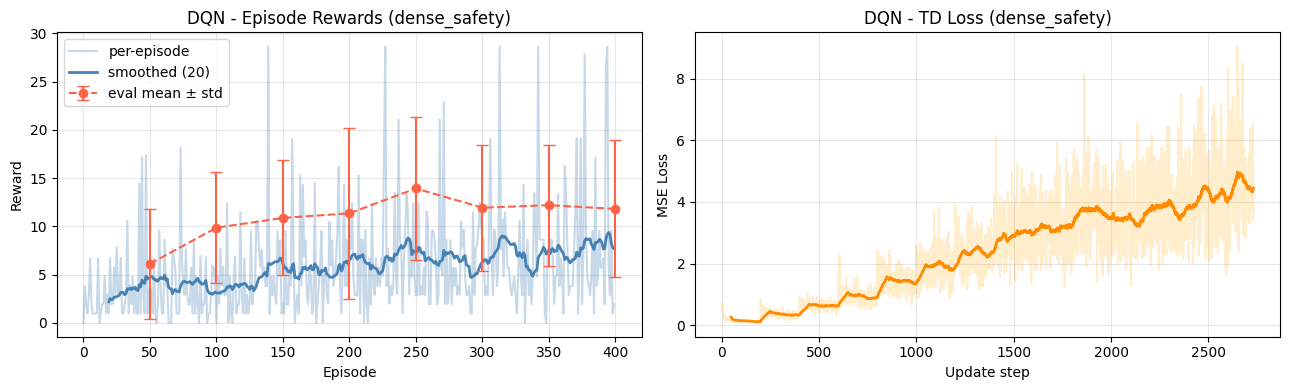

In [26]:
def smooth(x, window=20):
    """Running mean for smoother visualisation."""
    return np.convolve(x, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Episode rewards
ax = axes[0]
ax.plot(ep_rewards, alpha=0.3, color='steelblue', label='per-episode')
ax.plot(range(19, len(ep_rewards)), smooth(ep_rewards), color='steelblue', lw=2, label='smoothed (20)')
ax.errorbar(eval_steps, eval_means, yerr=eval_stds, fmt='o--', color='tomato',
            capsize=4, label='eval mean ± std')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title(f'DQN - Episode Rewards ({EXPERIMENT_NAME})')
ax.legend()
ax.grid(alpha=0.3)

# TD Loss
ax = axes[1]
ax.plot(losses, alpha=0.2, color='orange')
if len(losses) > 50:
    ax.plot(range(49, len(losses)), smooth(losses, 50), color='darkorange', lw=2)
ax.set_xlabel('Update step')
ax.set_ylabel('MSE Loss')
ax.set_title(f'DQN - TD Loss ({EXPERIMENT_NAME})')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'dqn_training_curves_{EXPERIMENT_NAME}.png', dpi=120)
plt.show()

### 3.2 Save checkpoint

In [27]:
checkpoint_path = f'checkpoints/dqn_{EXPERIMENT_NAME}.pt'
torch.save(dqn_agent.q_net.state_dict(), checkpoint_path)
print(f"Checkpoint saved to {checkpoint_path}")

Checkpoint saved to checkpoints/dqn_dense_safety.pt
